In [8]:
import numpy as np
import scipy.signal as sg
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm


In [9]:
def difference_vectorized(x, W, max_tau):
    diff = np.zeros(max_tau + 1)
    for tau in range(max_tau + 1):
        # Shift and subtract
        diff[tau] = np.sum((x[1:W-tau] - x[1+tau:W])**2)
    return diff

In [10]:
def computeCmndf(x, W, min_tau, max_tau):
    diff = difference_vectorized(x, W, max_tau)
    cmndf = np.empty(max_tau - min_tau)

    # Must accumulate from j=1, not from min_tau
    running_sum = 0.0
    for j in range(1, min_tau):
        running_sum += diff[j]          # build up sum before the window

    for tau in range(min_tau, max_tau):
        running_sum += diff[tau]        # now add current tau (once, correctly)
        cumulative_mean = running_sum / tau
        # cmndf[tau - min_tau] = diff[tau] / cumulative_mean
        if cumulative_mean == 0:
            cmndf[tau - min_tau] = 1.0  # treat as unvoiced
        else:
            cmndf[tau - min_tau] = diff[tau] / cumulative_mean

    return cmndf

In [11]:
def find_first_local_min_below_threshold(array, threshold):
    # Find all local minima
    local_minima_indices = sg.argrelmin(array)[0]
    for idx in local_minima_indices:
        # Return the FIRST dip that drops below threshold
        if array[idx] < threshold:
            return idx
    return None

In [12]:
def parabolic_interp(y1, y2, y3):
    # Finds the fractional offset for the exact bottom of a parabola
    return 0.5 * (y1 - y3) / (y1 - 2*y2 + y3)

In [13]:
def pitchDetect(audio, fs, min_f0, max_f0, W, decimation_factor, cmndf_threshold):
    res = []

    # Downsample for speed
    downsampled_audio = sg.decimate(audio, decimation_factor, zero_phase=True)
    downsampled_fs = fs // decimation_factor

    # Calculate bounds based on DOWNSAMPLED frequency
    min_tau = downsampled_fs // max_f0
    max_tau = downsampled_fs // min_f0

    # 50% Overlapping frames
    step = W // 2
    length = (len(downsampled_audio) // step - 1) * step

    for start in tqdm(range(0, length, step), desc="Detecting Pitch"):
        x = downsampled_audio[start:start+W]
        if len(x) != W:
            break
            
        cmndf = computeCmndf(x, W, min_tau, max_tau)
        predicted_idx = find_first_local_min_below_threshold(cmndf, cmndf_threshold)
        
        if predicted_idx is not None:
            # Safety check so interpolation doesn't crash at the edges
            if 0 < predicted_idx < len(cmndf) - 1:
                y1 = cmndf[predicted_idx - 1]
                y2 = cmndf[predicted_idx]
                y3 = cmndf[predicted_idx + 1]
                
                interp_add = parabolic_interp(y1, y2, y3)
                
                # Convert array index back to actual lag
                actual_tau = min_tau + predicted_idx + interp_add
                f0 = downsampled_fs / actual_tau
                res.append(f0)
            else:
                res.append(None)
        else:
            res.append(None) # Unvoiced

        frame_energy = np.sqrt(np.mean(x**2))  # RMS energy
        if frame_energy < 0.05:                 # tune this value
            res.append(None)
            continue
            
    return np.array(res)

Starting in 3...
Starting in 2...
Starting in 1...
Recording... speak now
Done.


Detecting Pitch: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 343/343 [00:02<00:00, 167.34it/s]


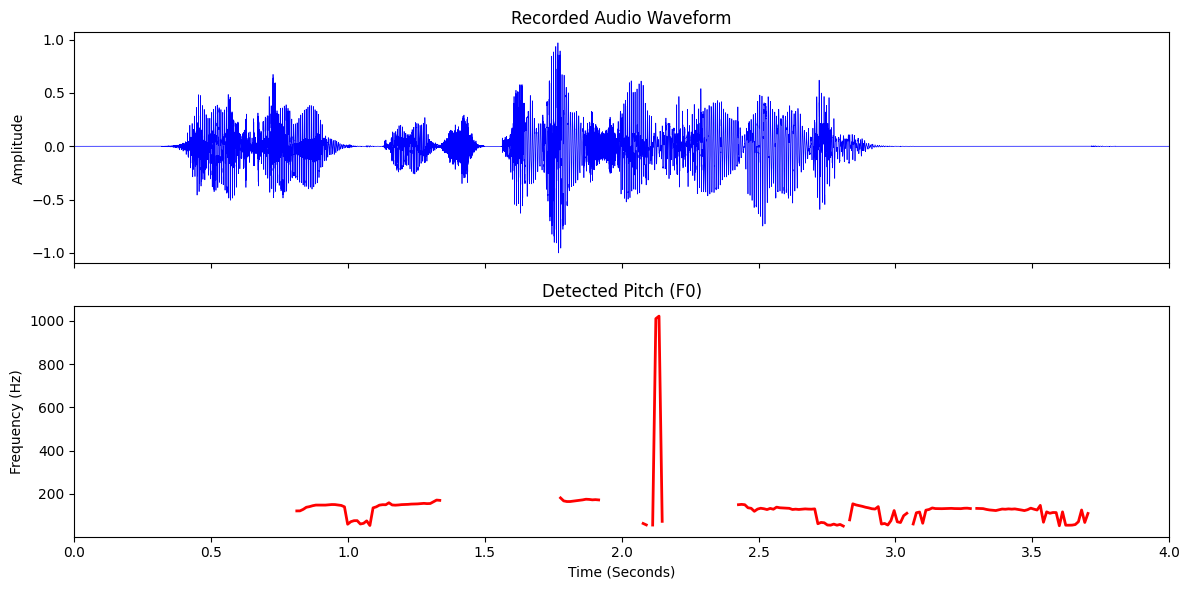

In [14]:
import sounddevice as sd
import numpy as np
import matplotlib.pyplot as plt
import time

SAMPLE_RATE = 44100
DURATION    = 4        # seconds to record
W           = 1024
THRESHOLD   = 0.30

def record():
    for i in [3, 2, 1]:
        print(f"Starting in {i}...")
        time.sleep(1)
    print("Recording... speak now")
    audio = sd.rec(int(DURATION * SAMPLE_RATE), 
                   samplerate=SAMPLE_RATE, 
                   channels=1, dtype='float32',device=2)
    sd.wait()  # blocks until done
    print("Done.")
    return audio.flatten()

def run():
    audio = record()
    
    # Normalize
    audio = audio / (np.max(np.abs(audio)) + 1e-9)
    
    # Run your existing YIN
    pitch_contour = pitchDetect(audio, SAMPLE_RATE,
                                min_f0=50, max_f0=1500,
                                W=W,decimation_factor=1, cmndf_threshold=THRESHOLD)
    
    # Plot
    step       = W // 2
    time_steps = np.arange(len(pitch_contour)) * step / SAMPLE_RATE
    time_audio = np.linspace(0, len(audio) / SAMPLE_RATE, len(audio))

  
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Top Graph
    # time_audio = np.linspace(0, len(audio) / fs, len(audio))
    ax1.plot(time_audio, audio, color='b', linewidth=0.5)
    ax1.set_title("Recorded Audio Waveform")
    ax1.set_ylabel("Amplitude")
    ax1.set_xlim(0, DURATION)
    
    # Bottom Graph
    time_steps = np.arange(len(pitch_contour)) * step / SAMPLE_RATE
    clean_pitch = np.where(pitch_contour == None, np.nan, pitch_contour)
    ax2.plot(time_steps, clean_pitch, color='r', linewidth=2)
    ax2.set_title("Detected Pitch (F0)")
    ax2.set_xlabel("Time (Seconds)")
    ax2.set_ylabel("Frequency (Hz)")
    
    plt.tight_layout()
    plt.show()

run()